# IoT Packet-Loss Risk - Data Preparation Notebook

**Thesis project:** IoT Packet Loss Reduction using ML

**Dataset:** TON_IoT - `Train_Test_Network.csv` (UNSW Canberra Cyber), downloaded from Kaggle. Built originally for **intrusion detection**, not packet loss - so the loss label is *derived*, not provided.

**Design rule for this notebook:** every code cell performs exactly one action, so the whole pipeline can be re-run end-to-end (`Kernel -> Restart & Run All`) with no manual steps in between.

**Three files involved:**

| File | What it is |
|---|---|
| `train_test_network.csv` | Raw file from Kaggle - **read-only**, never modified or overwritten by this notebook |
| `network_data_columns_selected.csv` | Same rows as the raw file, irrelevant columns removed (Step 1 output) |
| `network_data_cleaned_features.csv` | Final dataset: deduplicated, cleaned, with 8 new engineered columns (Step 2 + Step 3 output) - loaded next by `02_model_selection_analysis.ipynb`, which is where the model family gets picked (not asserted here) |

## Contents

1. Load the raw dataset (read-only)
2. Explore & decide which columns to keep
   - 2a. Understanding the target composition before cleaning
   - 2b. The real target signal: `missed_bytes`
   - 2c. Column decision
3. Step 1 - remove columns, and *only* columns
4. Step 2 - clean the data
   - 4a. Duplicate rows - why the definition matters
   - 4b. Apply the safe duplicate definition
   - 4c. Missing values - what's actually "missing" here?
   - 4d. A general row/cell cleaning rule
5. Step 3 - feature engineering (one new column per cell)
6. Sanity-check the finished dataset
7. Save the final dataset
8. Recap

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RAW_PATH = 'train_test_network.csv'

print('Environment ready.')

Matplotlib is building the font cache; this may take a moment.


Environment ready.


## Section 1 - Load the raw dataset (read-only)

We load the Kaggle file into `df_raw` and only ever *read* from it from this point on. No cell in this notebook writes back to `train_test_network.csv`.

In [2]:
df_raw = pd.read_csv(RAW_PATH)
print('Shape:', df_raw.shape)
df_raw.head()

Shape: (211043, 44)


,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,dns_query,dns_qclass,dns_qtype,dns_rcode,dns_AA,dns_RD,dns_RA,dns_rejected,ssl_version,ssl_cipher,ssl_resumed,ssl_established,ssl_subject,ssl_issuer,http_trans_depth,http_method,http_uri,http_version,http_request_body_len,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,0,108,108064,31,3832,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,0,1,52,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,0,1,52,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,0,1,48,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,0,1,52,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor


The raw export has **211,043 rows and 44 columns**. It's a flattened Zeek network log: every row is one network connection, and the 44 columns mix core traffic statistics with protocol-specific fields (DNS/SSL/HTTP) that only apply to a minority of connections.

In [3]:
df_raw.dtypes.value_counts()

str        27
int64      16
float64     1
Name: count, dtype: int64

## Section 2 - Explore & decide which columns to keep

Rather than dropping columns by guesswork, we measure how often each column is actually populated. Zeek marks a field as **not applicable to this connection** with a literal `"-"` string (e.g. an HTTP field on a connection that was never HTTP). A column that's 90%+ `"-"` isn't "dirty" - it's telling us that protocol simply never occurred in most rows, so it can't carry a general packet-loss signal.

In [4]:
def placeholder_pct(df):
    pct = {}
    for c in df.columns:
        try:
            n = (df[c].astype(str) == '-').sum()
        except Exception:
            n = 0
        if n > 0:
            pct[c] = round(n / len(df) * 100, 1)
    return pd.Series(pct).sort_values(ascending=True)

sparsity = placeholder_pct(df_raw)
sparsity

service                  62.6
dns_AA                   83.4
dns_RD                   83.4
dns_RA                   83.4
dns_rejected             83.4
dns_query                83.5
ssl_version              99.8
ssl_cipher               99.8
ssl_resumed              99.8
ssl_established          99.8
weird_notice             99.8
weird_name               99.8
http_uri                 99.9
http_version             99.9
http_method              99.9
http_trans_depth         99.9
weird_addl               99.9
http_user_agent          99.9
http_resp_mime_types     99.9
ssl_issuer              100.0
ssl_subject             100.0
http_orig_mime_types    100.0
dtype: float64

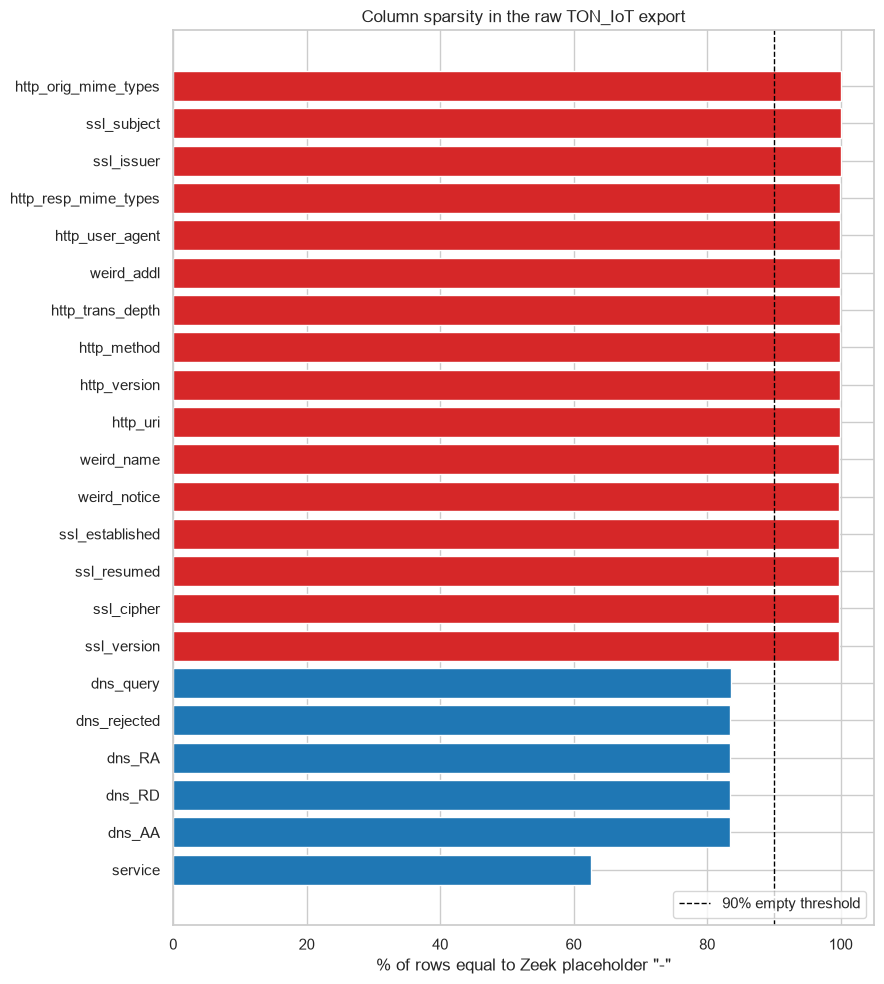

In [5]:
plt.figure(figsize=(9, 10))
colors = ['#d62728' if v >= 90 else '#1f77b4' for v in sparsity.values]
plt.barh(sparsity.index, sparsity.values, color=colors)
plt.axvline(90, color='black', linestyle='--', linewidth=1, label='90% empty threshold')
plt.xlabel('% of rows equal to Zeek placeholder "-"')
plt.title('Column sparsity in the raw TON_IoT export')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 2a. Understanding the target composition before cleaning

Before deciding what "cleaning" even means for this data, it helps to see what's actually in it: how many rows are attacks vs. normal traffic, and how they break down by attack type. This dataset was built for **intrusion detection** - that's the `type` / `label` distinction - not for packet loss, which is why we need to derive our own target next.

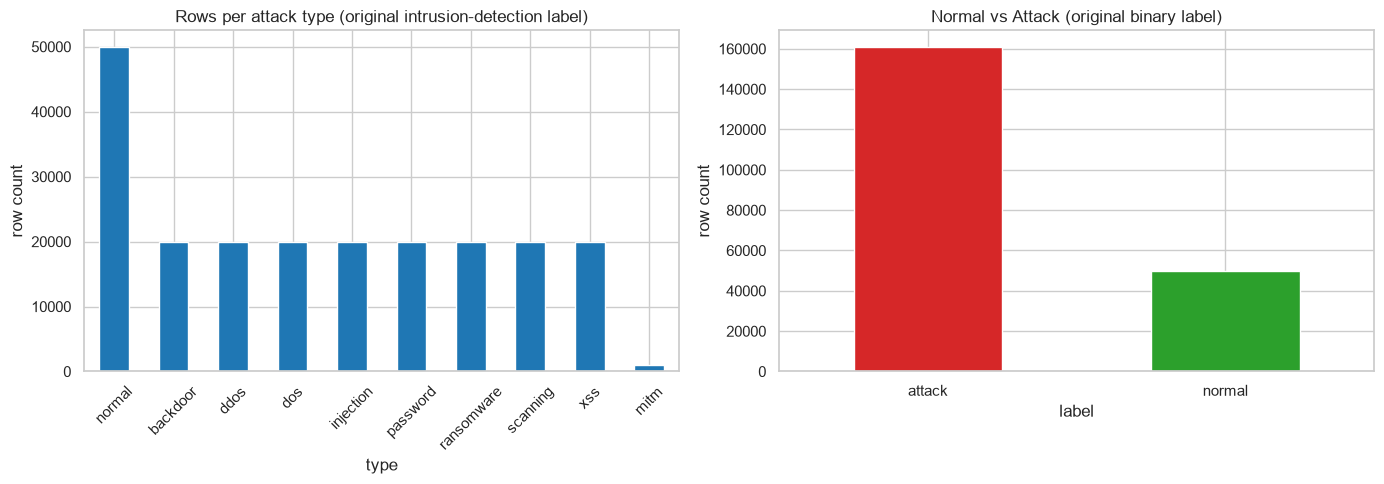

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_raw['type'].value_counts().plot(kind='bar', ax=axes[0], color='#1f77b4')
axes[0].set_title('Rows per attack type (original intrusion-detection label)')
axes[0].set_ylabel('row count')
axes[0].tick_params(axis='x', rotation=45)

df_raw['label'].value_counts().rename({0: 'normal', 1: 'attack'}).plot(
    kind='bar', ax=axes[1], color=['#d62728', '#2ca02c']
)
axes[1].set_title('Normal vs Attack (original binary label)')
axes[1].set_ylabel('row count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 2b. The real target signal: `missed_bytes`

`missed_bytes` - bytes Zeek saw were never delivered - is the only column that directly represents loss. It will become our `packet_lost` label. As the chart below shows, loss is a genuinely rare event in this data, which matters for model evaluation later (plain accuracy would be a misleading metric on this kind of imbalance).

missed_bytes == 0 : 208,098 rows (98.60%)
missed_bytes  > 0 : 2,945 rows (1.40%)


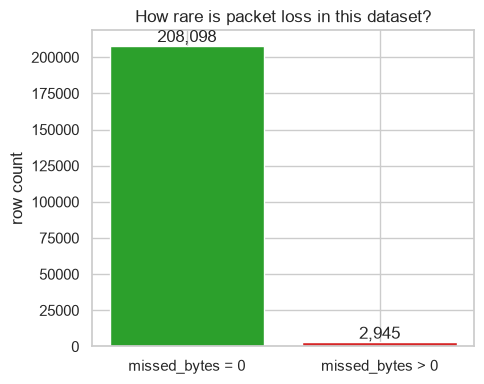

In [7]:
zero = int((df_raw['missed_bytes'] == 0).sum())
nonzero = int((df_raw['missed_bytes'] > 0).sum())
print(f"missed_bytes == 0 : {zero:,} rows ({zero/len(df_raw)*100:.2f}%)")
print(f"missed_bytes  > 0 : {nonzero:,} rows ({nonzero/len(df_raw)*100:.2f}%)")

plt.figure(figsize=(5, 4))
bars = plt.bar(['missed_bytes = 0', 'missed_bytes > 0'], [zero, nonzero], color=['#2ca02c', '#d62728'])
plt.ylabel('row count')
plt.title('How rare is packet loss in this dataset?')
for b, v in zip(bars, [zero, nonzero]):
    plt.text(b.get_x() + b.get_width()/2, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

### 2c. Column decision

Based on the sparsity chart above:

- **Drop all DNS fields (8)** - `dns_query, dns_qclass, dns_qtype, dns_rcode, dns_AA, dns_RD, dns_RA, dns_rejected` - ~83% placeholder, and what they encode (query names, resolution flags) is about DNS-tunneling/attack detection, not about whether packets were lost.
- **Drop all SSL fields (6)** - `ssl_version, ssl_cipher, ssl_resumed, ssl_established, ssl_subject, ssl_issuer` - ~99.8-100% placeholder (only ~400 of 211,043 rows have any SSL handshake logged at all).
- **Drop all HTTP fields (10)** - `http_trans_depth, http_method, http_uri, http_version, http_request_body_len, http_response_body_len, http_status_code, http_user_agent, http_orig_mime_types, http_resp_mime_types` - ~99.9% placeholder; the few populated rows encode XSS/injection payload signatures - attack-fingerprinting information, not congestion/loss information.
- **Drop Zeek's own anomaly notes (3)** - `weird_name, weird_addl, weird_notice` - ~99.8% placeholder, and Zeek raises these for protocol violations tied to attacks, not to network-layer loss.
- **Drop `src_port`** - ephemeral, effectively random per connection (26,628 unique values); it can't generalize.

Everything else is kept, including `label` and `type` - they stay **in the file** for reference/EDA, but are excluded from the model's feature set later, since `type` in particular leaks the answer (see the duplicate-detection nuance below for a concrete example of why that matters).

In [8]:
drop_cols = [
    'src_port',
    'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected',
    'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer',
    'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_request_body_len',
    'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types',
    'weird_name', 'weird_addl', 'weird_notice',
]

keep_cols = [c for c in df_raw.columns if c not in drop_cols]

assert len(drop_cols) + len(keep_cols) == df_raw.shape[1]
print(f"Dropping {len(drop_cols)} columns, keeping {len(keep_cols)} columns (out of {df_raw.shape[1]} total)")
keep_cols

Dropping 28 columns, keeping 16 columns (out of 44 total)


['src_ip',
 'dst_ip',
 'dst_port',
 'proto',
 'service',
 'duration',
 'src_bytes',
 'dst_bytes',
 'conn_state',
 'missed_bytes',
 'src_pkts',
 'src_ip_bytes',
 'dst_pkts',
 'dst_ip_bytes',
 'label',
 'type']

## Section 3 - Step 1: remove columns, and *only* columns

No rows are touched here. We select the 16 columns we're keeping and save the result as a new file - the original raw file is never written to.

In [9]:
df_step1 = df_raw[keep_cols].copy()
print('Rows unchanged:', len(df_step1) == len(df_raw))
print('Shape after column removal:', df_step1.shape)
df_step1.head()

Rows unchanged: True
Shape after column removal: (211043, 16)


,src_ip,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,label,type
0,192.168.1.37,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,0,108,108064,31,3832,1,backdoor
1,192.168.1.193,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,0,1,52,1,40,1,backdoor
2,192.168.1.193,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,0,1,52,1,40,1,backdoor
3,192.168.1.193,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,0,1,48,1,40,1,backdoor
4,192.168.1.193,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,0,1,52,1,40,1,backdoor


In [10]:
STEP1_PATH = 'network_data_columns_selected.csv'
df_step1.to_csv(STEP1_PATH, index=False)
print(f"Saved column-reduced dataset -> {STEP1_PATH}")

raw_header_check = pd.read_csv(RAW_PATH, nrows=0)
print(f"Original raw file still has {raw_header_check.shape[1]} columns (unchanged): {RAW_PATH}")

Saved column-reduced dataset -> network_data_columns_selected.csv
Original raw file still has 44 columns (unchanged): train_test_network.csv


## Section 4 - Step 2: clean the data

### 4a. Duplicate rows - why the definition matters

Simple `df.duplicated()` gives two very different answers depending on *when* you run it:

- On the **full 44-column raw record**: **20,569** rows are exact duplicates.
- On the **16-column trimmed record**: **97,122** rows look like duplicates.

The gap is not noise. The chart below breaks it down by attack type and shows the extra ~76,000 "duplicates" are concentrated in `scanning` and `ddos` - which is exactly what those attacks look like on the wire: a scan repeats near-identical probes, a flood repeats near-identical packets. Deduplicating on the trimmed columns would silently delete most of the scanning/DDoS traffic - attack types this thesis specifically cares about, since flooding is a classic cause of real packet loss.

**Decision: detect duplicates on the full original record, then apply that same row-selection to the trimmed dataset.** This is the one place where column-selection and duplicate-detection have to be decoupled.

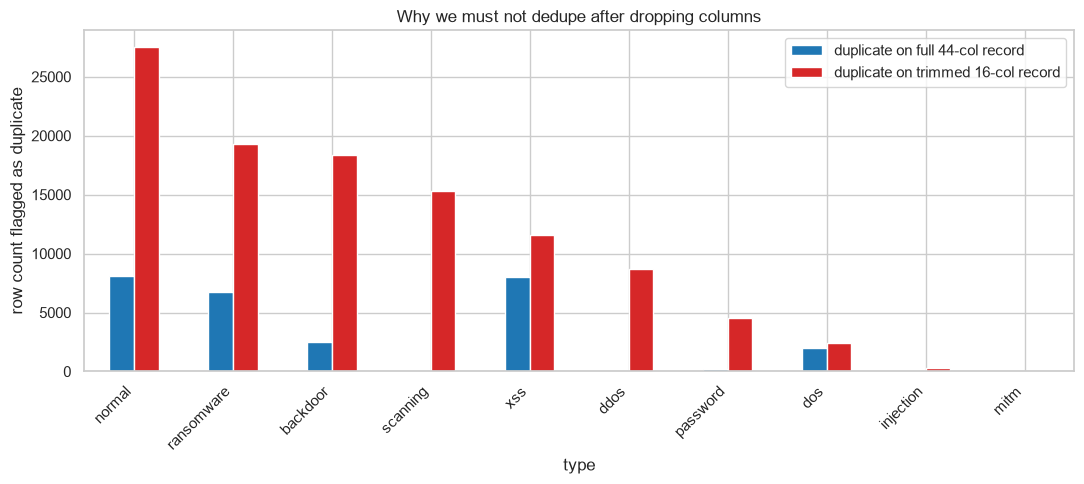

In [11]:
dup_full_mask = df_raw.duplicated(keep=False)
dup_trim_mask = df_raw[keep_cols].duplicated(keep=False)

full_counts = df_raw.loc[dup_full_mask, 'type'].value_counts()
trim_counts = df_raw.loc[dup_trim_mask, 'type'].value_counts()

comparison = pd.DataFrame({
    'duplicate on full 44-col record': full_counts,
    'duplicate on trimmed 16-col record': trim_counts,
}).fillna(0).sort_values('duplicate on trimmed 16-col record', ascending=False)

comparison.plot(kind='bar', figsize=(11, 5), color=['#1f77b4', '#d62728'])
plt.ylabel('row count flagged as duplicate')
plt.title('Why we must not dedupe after dropping columns')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4b. Apply the safe duplicate definition

In [12]:
dup_mask = df_raw.duplicated(keep='first')
print(f"True duplicate rows (identical across all {df_raw.shape[1]} original columns): {dup_mask.sum():,}")

True duplicate rows (identical across all 44 original columns): 20,569


In [13]:
df_step2 = df_step1.loc[~dup_mask].reset_index(drop=True)
print('Rows before dedup:', len(df_step1))
print('Rows after dedup :', len(df_step2))
print('Rows removed     :', len(df_step1) - len(df_step2))

Rows before dedup: 211043
Rows after dedup : 190474
Rows removed     : 20569


### 4c. Missing values - what's actually "missing" here?

Two different situations get lumped together as "missing data," and they need different treatment:

1. **True missing values (NaN/blank).** We checked - there are **zero** true NaNs across the 16 kept columns.
2. **`service == "-"`.** This is Zeek saying "no application-layer protocol was identified for this connection" - a legitimate state for raw TCP/UDP/ICMP traffic, not an error. Deleting or imputing these rows would be wrong; we simply recode it to a clear category, `"none"`.

In [14]:
print('Before recode:')
print(df_step2['service'].value_counts().head())

df_step2['service'] = df_step2['service'].replace('-', 'none')

print()
print('After recode:')
print(df_step2['service'].value_counts().head())

Before recode:
service
-       112640
dns      38269
http     37029
ftp       1065
ssl       1025
Name: count, dtype: int64

After recode:
service
none    112640
dns      38269
http     37029
ftp       1065
ssl       1025
Name: count, dtype: int64


### 4d. A general row/cell cleaning rule (for repeatability, not because this data needs it)

The rule we're following: if a row is missing several fields at once, it's too unreliable to trust - drop it. If it's just missing one field, keep the row and fill that one gap rather than throwing away everything else in it.

Concretely, over the feature columns (excluding `label`/`type`, which are metadata, not features):
- **≥ 2 missing fields → drop the row.**
- **Exactly 1 missing field → impute** with the column **median** for numeric columns (not the mean - byte/packet counts are heavily right-skewed, so a few huge flows would drag the mean up) or the **mode** for categorical columns.

Because this dataset has 0 true NaNs after the `service` recode, this cell will report 0 rows dropped and 0 values imputed **right now** - but it's written generically so it keeps working correctly if you rerun this notebook later on a fresh or appended TON_IoT export that isn't as clean.

In [15]:
feature_cols_for_missing_check = [c for c in keep_cols if c not in ('label', 'type')]

def clean_missing(df, cols, drop_threshold=2):
    working = df.copy()
    missing_mask = working[cols].isnull()
    missing_count_per_row = missing_mask.sum(axis=1)

    to_drop = missing_count_per_row >= drop_threshold
    dropped_rows = int(to_drop.sum())
    working = working.loc[~to_drop].reset_index(drop=True)
    missing_mask = missing_mask.loc[~to_drop].reset_index(drop=True)

    to_impute_rows = missing_mask.sum(axis=1) == 1
    impute_report = {}
    for col in cols:
        col_missing = missing_mask[col] & to_impute_rows
        n_missing = int(col_missing.sum())
        if n_missing == 0:
            continue
        if pd.api.types.is_numeric_dtype(working[col]):
            fill_value = working[col].median()
        else:
            fill_value = working[col].mode(dropna=True).iloc[0]
        working.loc[col_missing, col] = fill_value
        impute_report[col] = {'rows_imputed': n_missing, 'fill_value': fill_value}

    return working, dropped_rows, impute_report

df_step2, n_dropped, impute_report = clean_missing(df_step2, feature_cols_for_missing_check, drop_threshold=2)

print(f"Rows dropped (>=2 missing fields): {n_dropped}")
print(f"Columns that needed single-value imputation: {len(impute_report)}")
impute_report

Rows dropped (>=2 missing fields): 0


Columns that needed single-value imputation: 0


{}

In [16]:
print('Remaining true NaN values:', df_step2.isnull().sum().sum())
print('Remaining exact duplicate rows:', df_step2.duplicated().sum())
print('Shape after Step 2 (cleaning complete):', df_step2.shape)
df_step2.head()

Remaining true NaN values: 0


Remaining exact duplicate rows: 76553
Shape after Step 2 (cleaning complete): (190474, 16)


,src_ip,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,label,type
0,192.168.1.37,192.168.1.193,49178,tcp,none,290.371539,101568,2592,OTH,0,108,108064,31,3832,1,backdoor
1,192.168.1.193,192.168.1.37,8080,tcp,none,0.000102,0,0,REJ,0,1,52,1,40,1,backdoor
2,192.168.1.193,192.168.1.37,8080,tcp,none,0.000148,0,0,REJ,0,1,52,1,40,1,backdoor
3,192.168.1.193,192.168.1.37,8080,tcp,none,0.000113,0,0,REJ,0,1,48,1,40,1,backdoor
4,192.168.1.193,192.168.1.37,8080,tcp,none,0.000130,0,0,REJ,0,1,52,1,40,1,backdoor


## Section 5 - Step 3: feature engineering - one new column per cell

Eight new columns get added on top of the 16 kept ones. `label` and `type` stay in the file as reference metadata for exploratory analysis (e.g. "which attack type correlates with loss") but will **not** be fed into the classifier later.

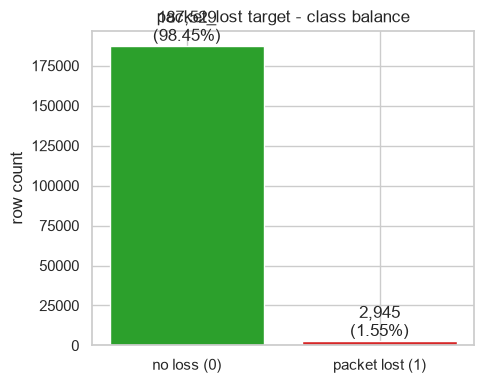

In [17]:
df_final = df_step2.copy()

df_final['packet_lost'] = (df_final['missed_bytes'] > 0).astype(int)

counts = df_final['packet_lost'].value_counts().reindex([0, 1], fill_value=0)
pct = (counts / len(df_final) * 100).round(2)

plt.figure(figsize=(5, 4))
bars = plt.bar(['no loss (0)', 'packet lost (1)'], counts.values, color=['#2ca02c', '#d62728'])
plt.ylabel('row count')
plt.title('packet_lost target - class balance')
for bar, c, p in zip(bars, counts.values, pct.values):
    plt.text(bar.get_x() + bar.get_width()/2, c, f'{c:,}\n({p}%)', ha='center', va='bottom')
plt.tight_layout()
plt.show()

`total_bytes` / `total_pkts` are simple directional sums - how much traffic and how many packets moved in *either* direction on the connection. They feed directly into `avg_pkt_size` next.

In [18]:
df_final['total_bytes'] = df_final['src_bytes'] + df_final['dst_bytes']
df_final[['src_bytes', 'dst_bytes', 'total_bytes']].head()

,src_bytes,dst_bytes,total_bytes
0,101568,2592,104160
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0


In [19]:
df_final['total_pkts'] = df_final['src_pkts'] + df_final['dst_pkts']
df_final[['src_pkts', 'dst_pkts', 'total_pkts']].head()

,src_pkts,dst_pkts,total_pkts
0,108,31,139
1,1,1,2
2,1,1,2
3,1,1,2
4,1,1,2


`avg_pkt_size` = `total_bytes / total_pkts`. 7,171 rows have 0 total packets (e.g. connections rejected before any data moved) - plain division would produce `inf`/`NaN`, so those rows get `avg_pkt_size = 0` instead.

In [20]:
zero_pkt_rows = int((df_final['total_pkts'] == 0).sum())
print(f"Rows with 0 total packets (would cause divide-by-zero): {zero_pkt_rows}")

df_final['avg_pkt_size'] = np.where(
    df_final['total_pkts'] == 0,
    0,
    df_final['total_bytes'] / df_final['total_pkts']
)
df_final[['total_bytes', 'total_pkts', 'avg_pkt_size']].head()

Rows with 0 total packets (would cause divide-by-zero): 423


,total_bytes,total_pkts,avg_pkt_size
0,104160,139,749.352518
1,0,2,0.000000
2,0,2,0.000000
3,0,2,0.000000
4,0,2,0.000000


`ip_byte_overhead` approximates retransmission/header overhead (Zeek doesn't log retransmit counts directly): `(src_ip_bytes - src_bytes) + (dst_ip_bytes - dst_bytes)`. 1,890 rows show a *negative* raw value (down to about -3.9 billion) - physically impossible, since IP-layer bytes can't be less than payload bytes, so these are capture/logging artifacts. We clip at 0.

In [21]:
raw_overhead = (df_final['src_ip_bytes'] - df_final['src_bytes']) + (df_final['dst_ip_bytes'] - df_final['dst_bytes'])
n_negative = int((raw_overhead < 0).sum())
print(f"Rows with a negative raw overhead (physically impossible - capture artifact): {n_negative}")
print(f"Most negative raw value seen: {raw_overhead.min():,}")

df_final['ip_byte_overhead'] = raw_overhead.clip(lower=0)
df_final[['src_ip_bytes', 'src_bytes', 'dst_ip_bytes', 'dst_bytes', 'ip_byte_overhead']].head()

Rows with a negative raw overhead (physically impossible - capture artifact): 1890
Most negative raw value seen: -3,913,849,079


,src_ip_bytes,src_bytes,dst_ip_bytes,dst_bytes,ip_byte_overhead
0,108064,101568,3832,2592,7736
1,52,0,40,0,92
2,52,0,40,0,92
3,48,0,40,0,88
4,52,0,40,0,92


`is_incomplete_conn` flags connections that never completed cleanly (`conn_state` in S0/REJ/RSTO/RSTR/RSTOS0/RSTRH). The chart checks whether that actually correlates with our target before we trust it as a feature.

is_incomplete_conn
1    97606
0    92868
Name: count, dtype: int64


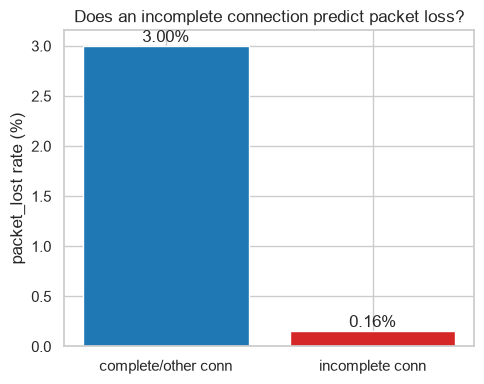

In [22]:
incomplete_states = {'S0', 'REJ', 'RSTO', 'RSTR', 'RSTOS0', 'RSTRH'}
df_final['is_incomplete_conn'] = df_final['conn_state'].isin(incomplete_states).astype(int)

print(df_final['is_incomplete_conn'].value_counts())

loss_rate = df_final.groupby('is_incomplete_conn')['packet_lost'].mean() * 100

plt.figure(figsize=(5, 4))
plt.bar(['complete/other conn', 'incomplete conn'], loss_rate.values, color=['#1f77b4', '#d62728'])
plt.ylabel('packet_lost rate (%)')
plt.title('Does an incomplete connection predict packet loss?')
for i, v in enumerate(loss_rate.values):
    plt.text(i, v, f'{v:.2f}%', ha='center', va='bottom')
plt.tight_layout()
plt.show()

`conn_count_per_src_ip` is our stand-in for the "concurrent connections / congestion" signal from the project brief. This export has **no timestamp column**, so true time-windowed concurrency can't be computed - this is the closest available proxy: how many total connections each source device generates across the whole capture.

In [23]:
df_final['conn_count_per_src_ip'] = df_final.groupby('src_ip')['src_ip'].transform('count')
df_final[['src_ip', 'conn_count_per_src_ip']].drop_duplicates().sort_values('conn_count_per_src_ip', ascending=False).head(10)

,src_ip,conn_count_per_src_ip
18711,192.168.1.30,60551
18720,192.168.1.31,30245
155360,192.168.1.32,22402
1,192.168.1.193,21708
77912,192.168.1.152,15110
101,192.168.1.33,7284
0,192.168.1.37,6374
78011,192.168.1.195,4180
100677,192.168.1.180,3681
47957,192.168.1.190,3134


`dst_port_bucket` groups the destination port into well-known (0-1023) / registered (1024-49151) / dynamic (49152-65535), plus a small `reserved/invalid` bucket for the 34 rows using port 0.

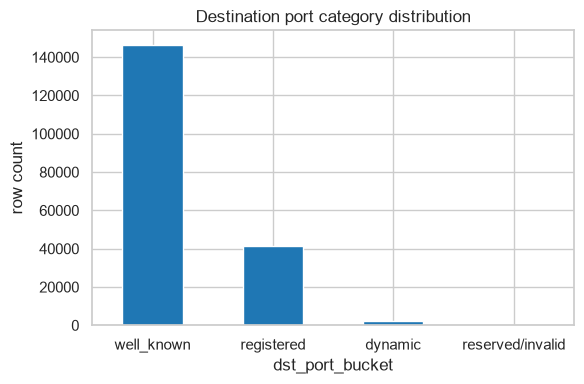

In [24]:
def bucket_port(p):
    if p == 0:
        return 'reserved/invalid'
    if p <= 1023:
        return 'well_known'
    if p <= 49151:
        return 'registered'
    return 'dynamic'

df_final['dst_port_bucket'] = df_final['dst_port'].apply(bucket_port)

order = df_final['dst_port_bucket'].value_counts().index
plt.figure(figsize=(6, 4))
df_final['dst_port_bucket'].value_counts().loc[order].plot(kind='bar', color='#1f77b4')
plt.ylabel('row count')
plt.title('Destination port category distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Section 6 - Sanity-check the finished dataset

Before saving, a quick visual check that the engineered features behave the way we'd expect and actually relate to `packet_lost`.

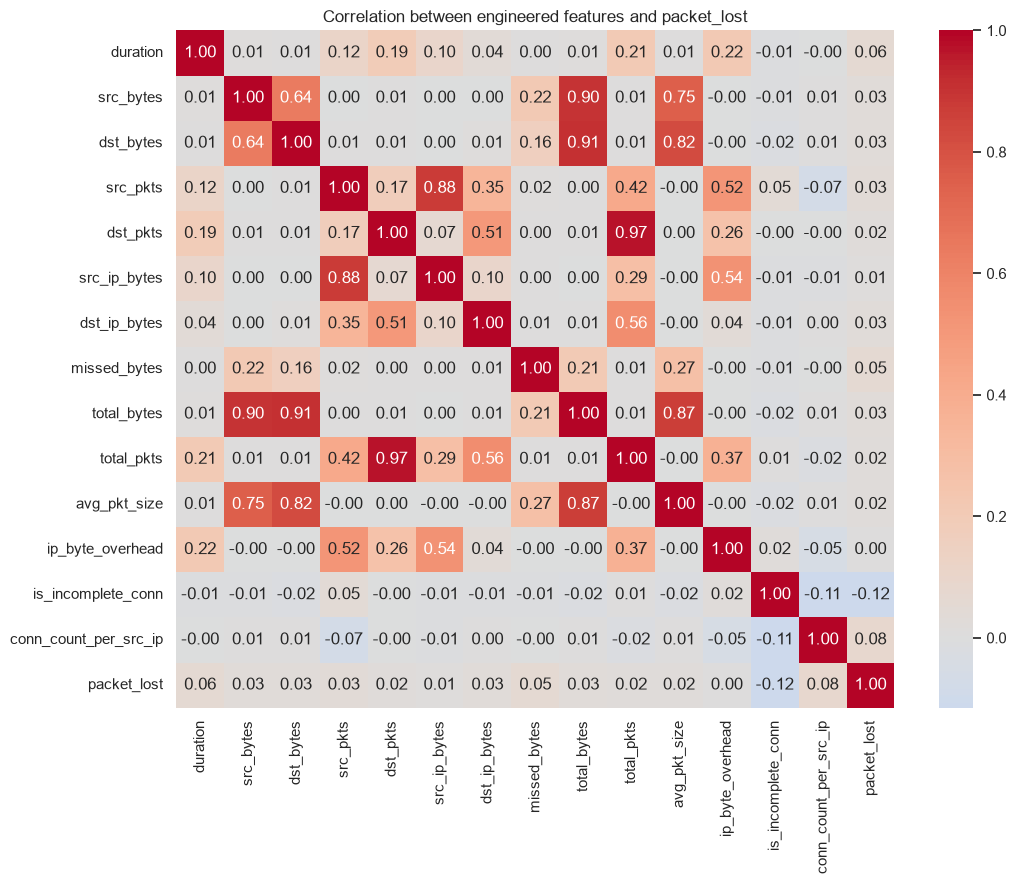

In [25]:
numeric_cols = [
    'duration', 'src_bytes', 'dst_bytes', 'src_pkts', 'dst_pkts', 'src_ip_bytes', 'dst_ip_bytes',
    'missed_bytes', 'total_bytes', 'total_pkts', 'avg_pkt_size', 'ip_byte_overhead',
    'is_incomplete_conn', 'conn_count_per_src_ip', 'packet_lost',
]

plt.figure(figsize=(11, 9))
sns.heatmap(df_final[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation between engineered features and packet_lost')
plt.tight_layout()
plt.show()

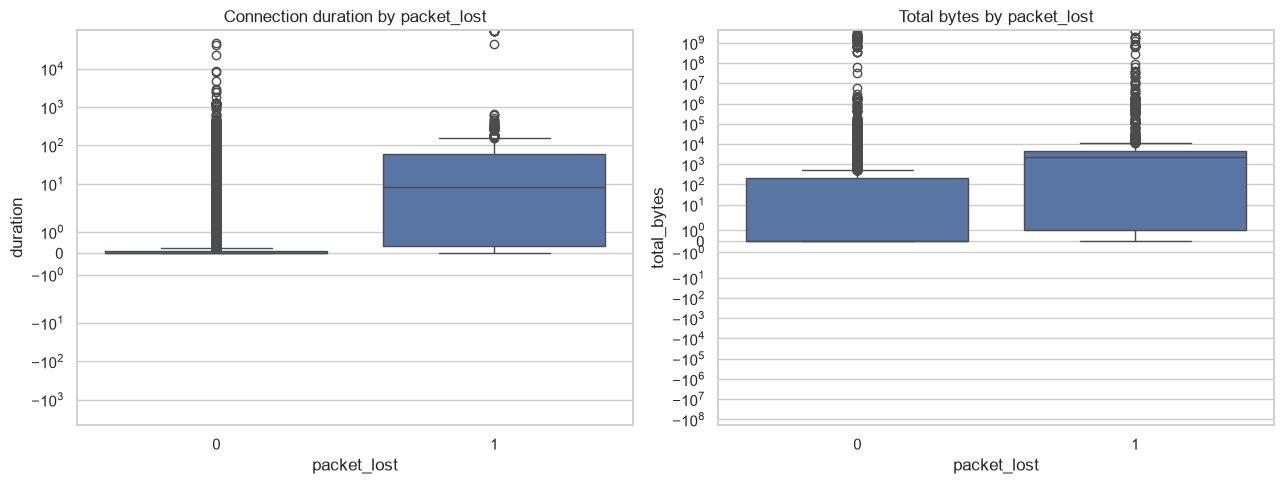

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_final, x='packet_lost', y='duration', ax=axes[0])
axes[0].set_yscale('symlog')
axes[0].set_title('Connection duration by packet_lost')

sns.boxplot(data=df_final, x='packet_lost', y='total_bytes', ax=axes[1])
axes[1].set_yscale('symlog')
axes[1].set_title('Total bytes by packet_lost')

plt.tight_layout()
plt.show()

In [27]:
df_final.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
src_ip,190474,51,192.168.1.30,60551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dst_ip,190474,753,192.168.1.190,47625,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dst_port,190474.0,NaN,NaN,NaN,2136.147989,6971.550976,0.0,53.0,80.0,445.0,65467.0
proto,190474,3,tcp,149596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service,190474,9,none,112640,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,190474.0,NaN,NaN,NaN,8.532477,593.815814,0.0,0.000009,0.000391,0.136369,93516.92917
src_bytes,190474.0,NaN,NaN,NaN,285986.833878,17994052.627984,0.0,0.0,0.0,130.0,3890855126.0
dst_bytes,190474.0,NaN,NaN,NaN,286752.486948,18973757.088004,0.0,0.0,0.0,178.0,3913853482.0
conn_state,190474,13,SF,50210,NaN,NaN,NaN,NaN,NaN,NaN,NaN
missed_bytes,190474.0,NaN,NaN,NaN,38150.641227,5538425.081686,0.0,0.0,0.0,0.0,1854527046.0


## Section 7 - Save the final dataset

In [28]:
FINAL_PATH = 'network_data_cleaned_features.csv'
df_final.to_csv(FINAL_PATH, index=False)

print(f"Final cleaned + feature-engineered dataset saved -> {FINAL_PATH}")
print(f"Final shape: {df_final.shape}")

raw_check = pd.read_csv(RAW_PATH, nrows=0)
print(f"Confirmed original raw file untouched: {RAW_PATH} still has {raw_check.shape[1]} columns")

Final cleaned + feature-engineered dataset saved -> network_data_cleaned_features.csv
Final shape: (190474, 24)
Confirmed original raw file untouched: train_test_network.csv still has 44 columns


## Recap - what this notebook did, end to end

1. **Loaded** `train_test_network.csv` (211,043 rows x 44 columns) - never modified.
2. **Measured sparsity** of every column to make a data-driven column-removal decision instead of a guess.
3. **Step 1 - dropped 28 columns** (all DNS/SSL/HTTP fields + `src_port`), kept 16, saved as `network_data_columns_selected.csv`. Row count unchanged (211,043).
4. **Step 2 - cleaned the data:**
   - Removed **20,569** exact duplicate rows, using a definition computed on the *full* 44-column record (not the trimmed one) to avoid deleting real scanning/DDoS traffic. Left with **190,474** rows.
   - Recoded the `service` placeholder `"-"` (62.6% of rows) to `"none"` - a valid category, not missing data.
   - Applied a general missing-value rule (drop rows with 2+ gaps, median/mode-impute rows with exactly 1 gap) - reported 0 rows affected, since this export had 0 true NaNs, but the logic stays in place for future re-runs on messier data.
5. **Step 3 - engineered 8 new columns:** `packet_lost` (target), `total_bytes`, `total_pkts`, `avg_pkt_size`, `ip_byte_overhead`, `is_incomplete_conn`, `conn_count_per_src_ip`, `dst_port_bucket`.
6. **Saved** the final 190,474-row x 24-column dataset as `network_data_cleaned_features.csv`.

**Known limitation carried forward:** this TON_IoT export has no timestamp column and no RSSI/signal-strength data, so true time-windowed congestion and burstiness features (called for in the original project brief) aren't computable from this source - `conn_count_per_src_ip` is the closest available proxy.
